In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 2, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 sec
Baseline,off


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X = epochs.get_data()
y = labels

X.shape

(576, 16, 52)

In [6]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler

n_blocks=4
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=None,
            max_iter=128,
            tol=1e-6,
            init ='svd',
            shrinkage=(0,0),
            toeplitz=None,
            obj='diff',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
    ),
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/4...
Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted tucker model of rank [2, 12] ...

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     11.52
Date:                Fri, 25 Aug 2023   Prob (F-statistic):           3.12e-35
Time:                        17:11:16   Log-Likelihood:                -131.68
No. Observations:                 576   AIC:                             313.4
Df Residuals:                     551   BIC:                             422.3
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

  0%|          | 0/128 [00:00<?, ?it/s]

Fitted tucker model of rank [3, 10] ...

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     8.160
Date:                Fri, 25 Aug 2023   Prob (F-statistic):           4.74e-42
Time:                        17:11:17   Log-Likelihood:                -72.263
No. Observations:                 576   AIC:                             254.5
Df Residuals:                     521   BIC:                             494.1
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

  0%|          | 0/128 [00:00<?, ?it/s]

Fitted tucker model of rank [4, 16] ...

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     6.982
Date:                Fri, 25 Aug 2023   Prob (F-statistic):           1.34e-52
Time:                        17:11:34   Log-Likelihood:                 48.032
No. Observations:                 576   AIC:                             141.9
Df Residuals:                     457   BIC:                             660.3
Df Model:                         118                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

  0%|          | 0/128 [00:00<?, ?it/s]

Fitted tucker model of rank [5, 20] ...

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     4.485
Date:                Fri, 25 Aug 2023   Prob (F-statistic):           2.55e-36
Time:                        17:11:50   Log-Likelihood:                 131.00
No. Observations:                 576   AIC:                             176.0
Df Residuals:                     357   BIC:                             1130.
Df Model:                         218                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

BTTDA(hoda_params={'init': 'svd', 'keep_train_info': False, 'max_iter': 128,
                   'obj': 'diff', 'rank': None, 'shrinkage': (0, 0),
                   'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                   'tol': 1e-06, 'verbose': True},
      keep_train_info=True, n_blocks=4, verbose=True)

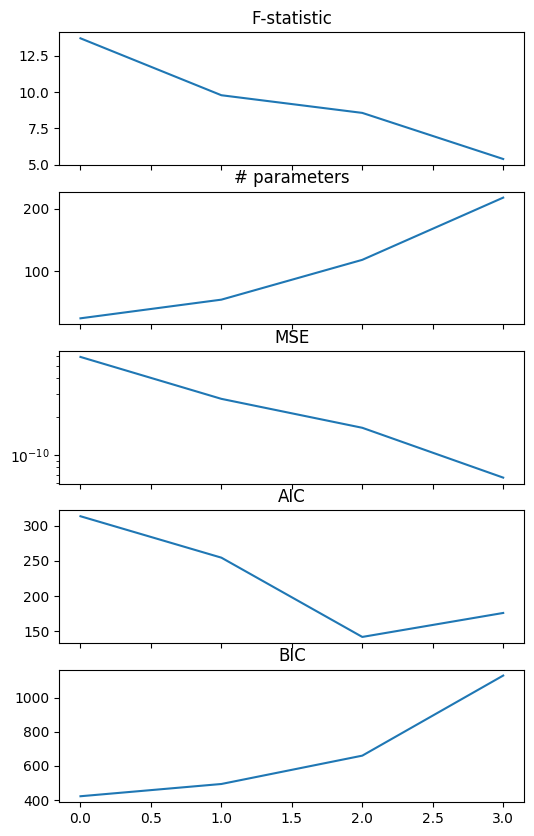

In [7]:
fig, axs = plt.subplots(5,1, sharex=True, figsize=(6,10))

axs[0].set_title('F-statistic')
axs[0].plot(bttda.train_info_["f_stat"])

axs[1].set_title('# parameters')
axs[1].plot(bttda.train_info_["n_params"])

axs[2].set_title('MSE')
axs[2].semilogy(bttda.train_info_["mse"])

axs[3].set_title('AIC')
axs[3].plot(bttda.train_info_["aic"])

axs[4].set_title('BIC')
axs[4].plot(bttda.train_info_["bic"])

In [8]:
import cupy

"""
fig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))
for b in range(len(bttda.blocks_)):
    for k in range(2):
        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(scatter_w))
        sns.heatmap(scatter_w, cmap='BrBG',
                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    
        axs[b,k].set_aspect('equal')
"""

"\nfig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))\nfor b in range(len(bttda.blocks_)):\n    for k in range(2):\n        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])\n        vmax = np.max(np.abs(scatter_w))\n        sns.heatmap(scatter_w, cmap='BrBG',\n                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    \n        axs[b,k].set_aspect('equal')\n"

No projector specified for this dataset. Please consider the method self.add_proj.


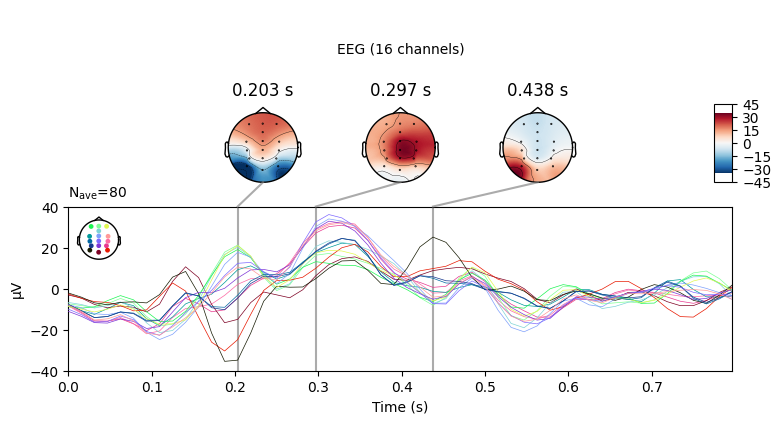

In [11]:
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-40,40])))


target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

In [12]:
from mne import combine_evoked
""""
for b in range(len(bttda.blocks_)):
    epochs_rec = epochs.copy()
    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))
    
    target = epochs_rec['Target'].average()
    non_target = epochs_rec['NonTarget'].average()
    contrast = combine_evoked([target,non_target], weights=[1,-1])
    _ = contrast.plot_joint(**joint_args)
"""

'"\nfor b in range(len(bttda.blocks_)):\n    epochs_rec = epochs.copy()\n    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))\n    \n    target = epochs_rec[\'Target\'].average()\n    non_target = epochs_rec[\'NonTarget\'].average()\n    contrast = combine_evoked([target,non_target], weights=[1,-1])\n    _ = contrast.plot_joint(**joint_args)\n'

In [13]:
Xt = bttda.transform(X)

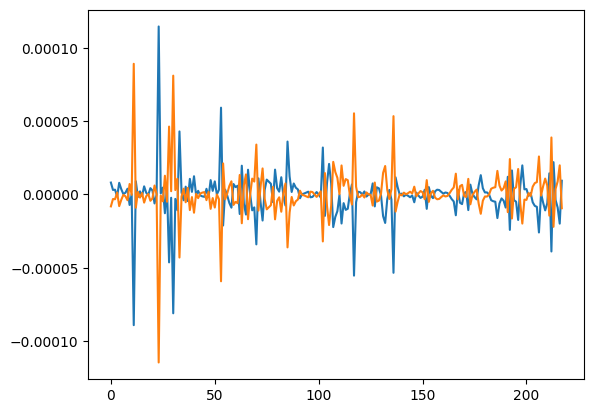

In [19]:
target_avg = cupy.asnumpy(Xt[y=='Target'].mean(axis=0))
nontarget_avg = cupy.asnumpy(Xt[y=='NonTarget'].mean(axis=0))
mean_avg = (target_avg+nontarget_avg)/2
target_avg -= mean_avg
nontarget_avg -= mean_avg
plt.plot(target_avg)
plt.plot(nontarget_avg)
plt.show()
